In [15]:
# Cell 1 — Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import os

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import OneHotEncoder, PolynomialFeatures
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import warnings
warnings.filterwarnings('ignore')



In [16]:
# Cell 2 — Load & Prepare Data
df = pd.read_csv('jobs_cambodia_cleaned_v2.csv')

# Clean education column
df['education_required'] = (
    df['education_required'].astype(str).str.lower().str.strip()
)

# Encode education as number
EDU_ORDER = {
    'none'       : 0,
    'high school': 1,
    'bachelor'   : 2,
    'master'     : 3,
    'phd'        : 4
}
df['edu_numeric'] = df['education_required'].map(EDU_ORDER)

# Keep only rows that have salary
df_model = df[df['salary_avg'].notna()].copy()
df_model = df_model[[
    'edu_numeric',
    'education_required',
    'category',
    'salary_avg'
]].dropna()

print(f"✅ Data ready")
print(f"   Total rows    : {len(df_model)}")
print(f"   Salary min    : ${df_model['salary_avg'].min():,.0f}")
print(f"   Salary max    : ${df_model['salary_avg'].max():,.0f}")
print(f"   Salary median : ${df_model['salary_avg'].median():,.0f}")
print(f"   Salary mean   : ${df_model['salary_avg'].mean():,.0f}")
print(f"   Job fields    : {df_model['category'].nunique()}")
print(f"   Edu levels    : {sorted(df_model['education_required'].unique())}")

✅ Data ready
   Total rows    : 1624
   Salary min    : $176
   Salary max    : $7,574
   Salary median : $1,915
   Salary mean   : $2,056
   Job fields    : 20
   Edu levels    : ['bachelor', 'high school', 'master', 'none', 'phd']


In [17]:
# Cell 3 — Features & Target
X = df_model[['edu_numeric', 'category']]
y = np.log1p(df_model['salary_avg'])  # log-transform because salary is skewed

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Train : {len(X_train)} rows")
print(f"Test  : {len(X_test)} rows")

Train : 1299 rows
Test  : 325 rows


In [18]:
# Cell 4 — Preprocessing
# education → keep as number
# category  → one-hot encode (convert text to 0/1 columns)
preprocessor = ColumnTransformer(transformers=[
    ('num', 'passthrough',
     ['edu_numeric']),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False),
     ['category'])
])

In [19]:
# Cell 5 — Build & Train Models

# ── Model 1: Linear Regression ────────────────────────────────────────────────
linear_pipe = Pipeline([
    ('pre',   preprocessor),
    ('model', LinearRegression())
])
linear_pipe.fit(X_train, y_train)

y_pred_linear = np.expm1(linear_pipe.predict(X_test))
y_true        = np.expm1(y_test)

rmse_linear = np.sqrt(mean_squared_error(y_true, y_pred_linear))
mae_linear  = mean_absolute_error(y_true, y_pred_linear)
r2_linear   = r2_score(y_true, y_pred_linear)
cv_linear   = cross_val_score(
    linear_pipe, X_train, y_train, cv=5, scoring='r2'
).mean()

print("=" * 50)
print("  Model 1 — Linear Regression")
print("=" * 50)
print(f"  R²      = {r2_linear:.4f}")
print(f"  CV R²   = {cv_linear:.4f}")
print(f"  RMSE    = ${rmse_linear:,.0f}/month")
print(f"  MAE     = ${mae_linear:,.0f}/month")

  Model 1 — Linear Regression
  R²      = 0.8512
  CV R²   = 0.9277
  RMSE    = $502/month
  MAE     = $333/month


In [20]:
# ── Model 2: Polynomial Regression (degree 2) ─────────────────────────────────
poly2_pipe = Pipeline([
    ('pre',   preprocessor),
    ('poly',  PolynomialFeatures(degree=2, include_bias=False)),
    ('model', LinearRegression())
])
poly2_pipe.fit(X_train, y_train)

y_pred_poly2 = np.expm1(poly2_pipe.predict(X_test))

rmse_poly2 = np.sqrt(mean_squared_error(y_true, y_pred_poly2))
mae_poly2  = mean_absolute_error(y_true, y_pred_poly2)
r2_poly2   = r2_score(y_true, y_pred_poly2)
cv_poly2   = cross_val_score(
    poly2_pipe, X_train, y_train, cv=5, scoring='r2'
).mean()

print("=" * 50)
print("  Model 2 — Polynomial Regression (degree=2)")
print("=" * 50)
print(f"  R²      = {r2_poly2:.4f}")
print(f"  CV R²   = {cv_poly2:.4f}")
print(f"  RMSE    = ${rmse_poly2:,.0f}/month")
print(f"  MAE     = ${mae_poly2:,.0f}/month")

  Model 2 — Polynomial Regression (degree=2)
  R²      = 0.8513
  CV R²   = 0.9256
  RMSE    = $502/month
  MAE     = $333/month


In [21]:
# ── Model 3: Polynomial Regression (degree 3) ─────────────────────────────────
poly3_pipe = Pipeline([
    ('pre',   preprocessor),
    ('poly',  PolynomialFeatures(degree=3, include_bias=False)),
    ('model', LinearRegression())
])
poly3_pipe.fit(X_train, y_train)

y_pred_poly3 = np.expm1(poly3_pipe.predict(X_test))

rmse_poly3 = np.sqrt(mean_squared_error(y_true, y_pred_poly3))
mae_poly3  = mean_absolute_error(y_true, y_pred_poly3)
r2_poly3   = r2_score(y_true, y_pred_poly3)
cv_poly3   = cross_val_score(
    poly3_pipe, X_train, y_train, cv=5, scoring='r2'
).mean()

print("=" * 50)
print("  Model 3 — Polynomial Regression (degree=3)")
print("=" * 50)
print(f"  R²      = {r2_poly3:.4f}")
print(f"  CV R²   = {cv_poly3:.4f}")
print(f"  RMSE    = ${rmse_poly3:,.0f}/month")
print(f"  MAE     = ${mae_poly3:,.0f}/month")

  Model 3 — Polynomial Regression (degree=3)
  R²      = 0.8471
  CV R²   = 0.9225
  RMSE    = $509/month
  MAE     = $340/month


In [22]:
# Cell 6 — Compare All Models
results = [
    {
        'Model'   : 'Linear Regression',
        'R²'      : r2_linear,
        'CV R²'   : cv_linear,
        'RMSE'    : rmse_linear,
        'MAE'     : mae_linear,
        'pipe'    : linear_pipe,
        'y_pred'  : y_pred_linear
    },
    {
        'Model'   : 'Polynomial (degree=2)',
        'R²'      : r2_poly2,
        'CV R²'   : cv_poly2,
        'RMSE'    : rmse_poly2,
        'MAE'     : mae_poly2,
        'pipe'    : poly2_pipe,
        'y_pred'  : y_pred_poly2
    },
    {
        'Model'   : 'Polynomial (degree=3)',
        'R²'      : r2_poly3,
        'CV R²'   : cv_poly3,
        'RMSE'    : rmse_poly3,
        'MAE'     : mae_poly3,
        'pipe'    : poly3_pipe,
        'y_pred'  : y_pred_poly3
    },
]

res_df = pd.DataFrame(results)[['Model','R²','CV R²','RMSE','MAE']]

print("\n📊 Model Comparison:")
print(f"\n  {'Model':<25} {'R²':>6} {'CV R²':>7} {'RMSE':>10} {'MAE':>10}")
print(f"  {'-'*60}")
for r in results:
    print(f"  {r['Model']:<25} {r['R²']:>6.4f} {r['CV R²']:>7.4f}"
          f"  ${r['RMSE']:>8,.0f}  ${r['MAE']:>8,.0f}")


📊 Model Comparison:

  Model                         R²   CV R²       RMSE        MAE
  ------------------------------------------------------------
  Linear Regression         0.8512  0.9277  $     502  $     333
  Polynomial (degree=2)     0.8513  0.9256  $     502  $     333
  Polynomial (degree=3)     0.8471  0.9225  $     509  $     340


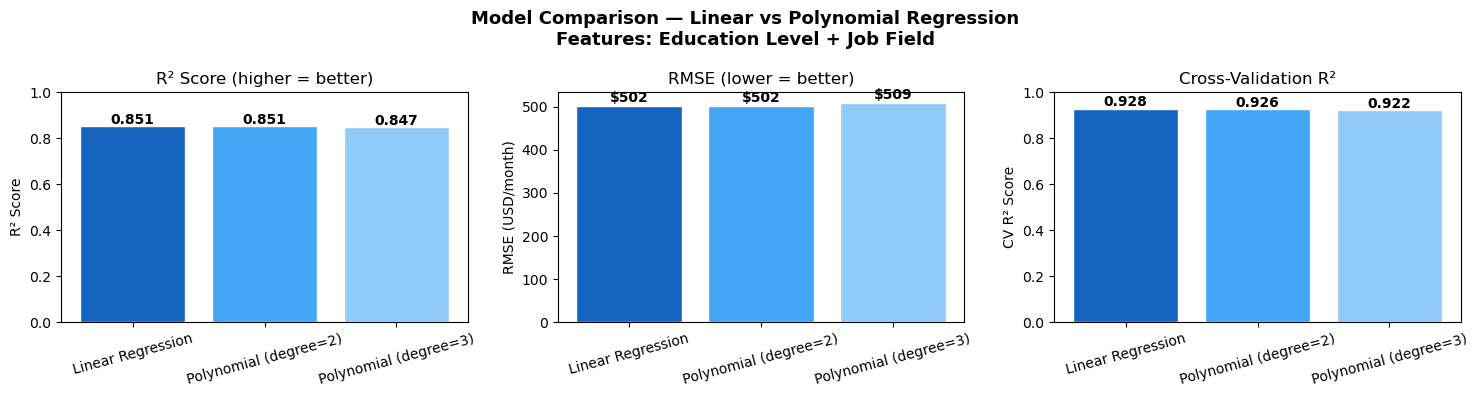

✅ Saved model_comparison.png


In [23]:
# Cell 7 — Plot 1: Model Comparison Bar Chart
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle(
    'Model Comparison — Linear vs Polynomial Regression\n'
    'Features: Education Level + Job Field',
    fontsize=13, fontweight='bold'
)
colors = ['#1565C0', '#42A5F5', '#90CAF9']

# R²
axes[0].bar(res_df['Model'], res_df['R²'], color=colors, edgecolor='white')
axes[0].set_ylabel('R² Score')
axes[0].set_title('R² Score (higher = better)')
axes[0].set_ylim(0, 1)
axes[0].tick_params(axis='x', rotation=15)
for i, v in enumerate(res_df['R²']):
    axes[0].text(i, v + 0.01, f'{v:.3f}', ha='center',
                 fontsize=10, fontweight='bold')

# RMSE
axes[1].bar(res_df['Model'], res_df['RMSE'], color=colors, edgecolor='white')
axes[1].set_ylabel('RMSE (USD/month)')
axes[1].set_title('RMSE (lower = better)')
axes[1].tick_params(axis='x', rotation=15)
for i, v in enumerate(res_df['RMSE']):
    axes[1].text(i, v + 10, f'${v:,.0f}', ha='center',
                 fontsize=10, fontweight='bold')

# CV R²
axes[2].bar(res_df['Model'], res_df['CV R²'], color=colors, edgecolor='white')
axes[2].set_ylabel('CV R² Score')
axes[2].set_title('Cross-Validation R²')
axes[2].set_ylim(0, 1)
axes[2].tick_params(axis='x', rotation=15)
for i, v in enumerate(res_df['CV R²']):
    axes[2].text(i, v + 0.01, f'{v:.3f}', ha='center',
                 fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('model_comparison.png', bbox_inches='tight', dpi=120)
plt.show()
print("✅ Saved model_comparison.png")

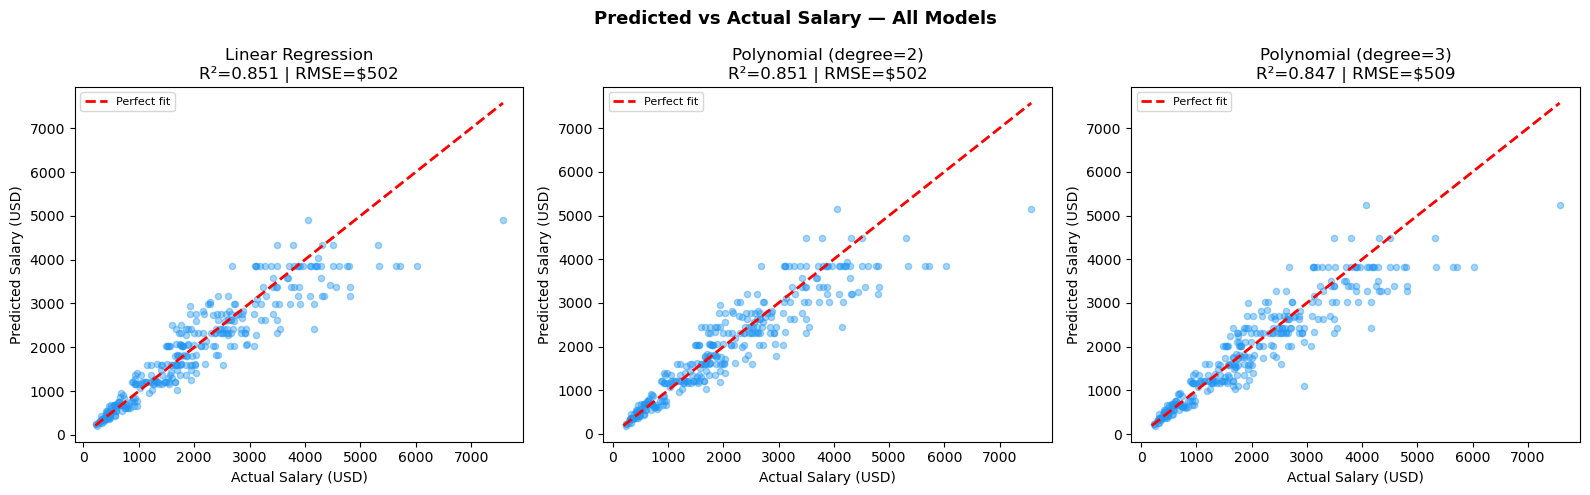

✅ Saved predicted_vs_actual.png


In [24]:
# Cell 8 — Plot 2: Predicted vs Actual (all 3 models)
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Predicted vs Actual Salary — All Models',
             fontsize=13, fontweight='bold')

for ax, r in zip(axes, results):
    ax.scatter(y_true, r['y_pred'], alpha=0.4, s=20, color='#2196F3')
    mn = min(y_true.min(), r['y_pred'].min())
    mx = max(y_true.max(), r['y_pred'].max())
    ax.plot([mn, mx], [mn, mx], 'r--', linewidth=2, label='Perfect fit')
    ax.set_xlabel('Actual Salary (USD)')
    ax.set_ylabel('Predicted Salary (USD)')
    ax.set_title(
        f"{r['Model']}\nR²={r['R²']:.3f} | RMSE=${r['RMSE']:,.0f}"
    )
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('predicted_vs_actual.png', bbox_inches='tight', dpi=120)
plt.show()
print("✅ Saved predicted_vs_actual.png")

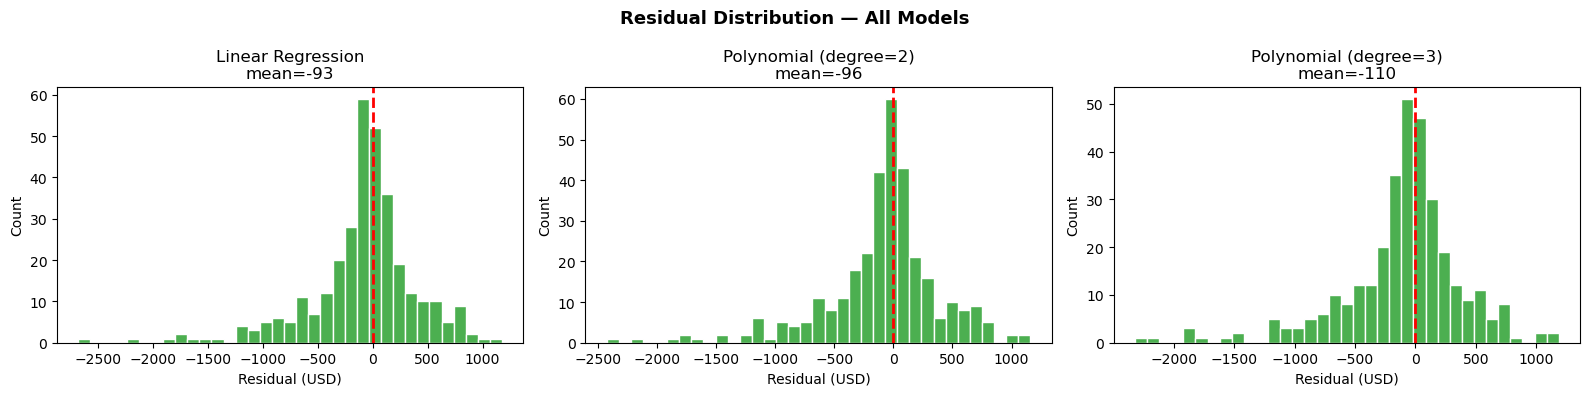

✅ Saved residuals.png


In [25]:
# Cell 9 — Plot 3: Residuals
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle('Residual Distribution — All Models',
             fontsize=13, fontweight='bold')

for ax, r in zip(axes, results):
    residuals = r['y_pred'] - y_true
    ax.hist(residuals, bins=35, color='#4CAF50', edgecolor='white')
    ax.axvline(0, color='red', linestyle='--', linewidth=2)
    ax.set_xlabel('Residual (USD)')
    ax.set_ylabel('Count')
    ax.set_title(f"{r['Model']}\nmean={residuals.mean():+,.0f}")

plt.tight_layout()
plt.savefig('residuals.png', bbox_inches='tight', dpi=120)
plt.show()
print("✅ Saved residuals.png")

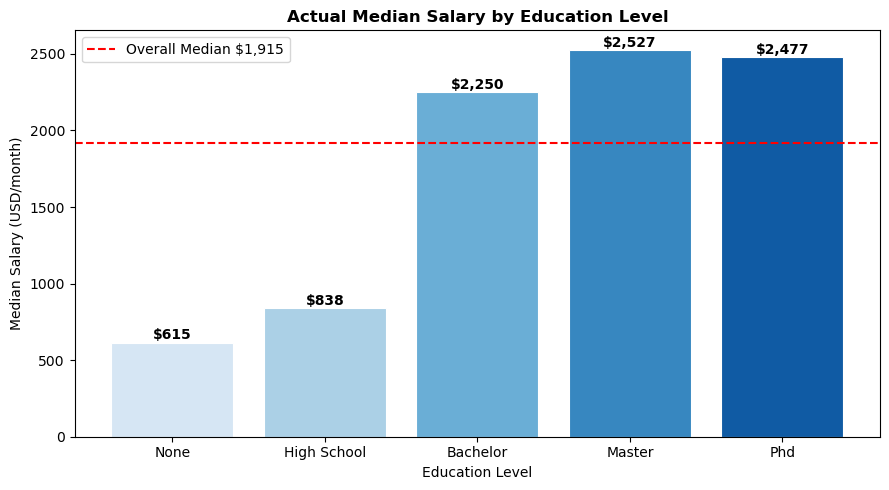

✅ Saved salary_by_education.png


In [26]:
# Cell 10 — Plot 4: Salary by Education Level (actual data)
edu_order = ['none', 'high school', 'bachelor', 'master', 'phd']
edu_median = (
    df_model.groupby('education_required')['salary_avg']
    .median()
    .reindex(edu_order)
)

fig, ax = plt.subplots(figsize=(9, 5))
colors = sns.color_palette('Blues', len(edu_order))
bars = ax.bar(
    [e.title() for e in edu_order],
    edu_median.values,
    color=colors, edgecolor='white', linewidth=0.8
)
ax.set_xlabel('Education Level')
ax.set_ylabel('Median Salary (USD/month)')
ax.set_title('Actual Median Salary by Education Level',
             fontweight='bold')
ax.axhline(
    df_model['salary_avg'].median(),
    color='red', linestyle='--', linewidth=1.5,
    label=f'Overall Median ${df_model["salary_avg"].median():,.0f}'
)
ax.legend()
for bar, val in zip(bars, edu_median.values):
    ax.text(
        bar.get_x() + bar.get_width()/2,
        val + 20, f'${val:,.0f}',
        ha='center', fontsize=10, fontweight='bold'
    )
plt.tight_layout()
plt.savefig('salary_by_education.png', bbox_inches='tight', dpi=120)
plt.show()
print("✅ Saved salary_by_education.png")

✅ Best Model : Polynomial (degree=2)
   R²         : 0.8513
   CV R²      : 0.9256
   RMSE       : $502/month


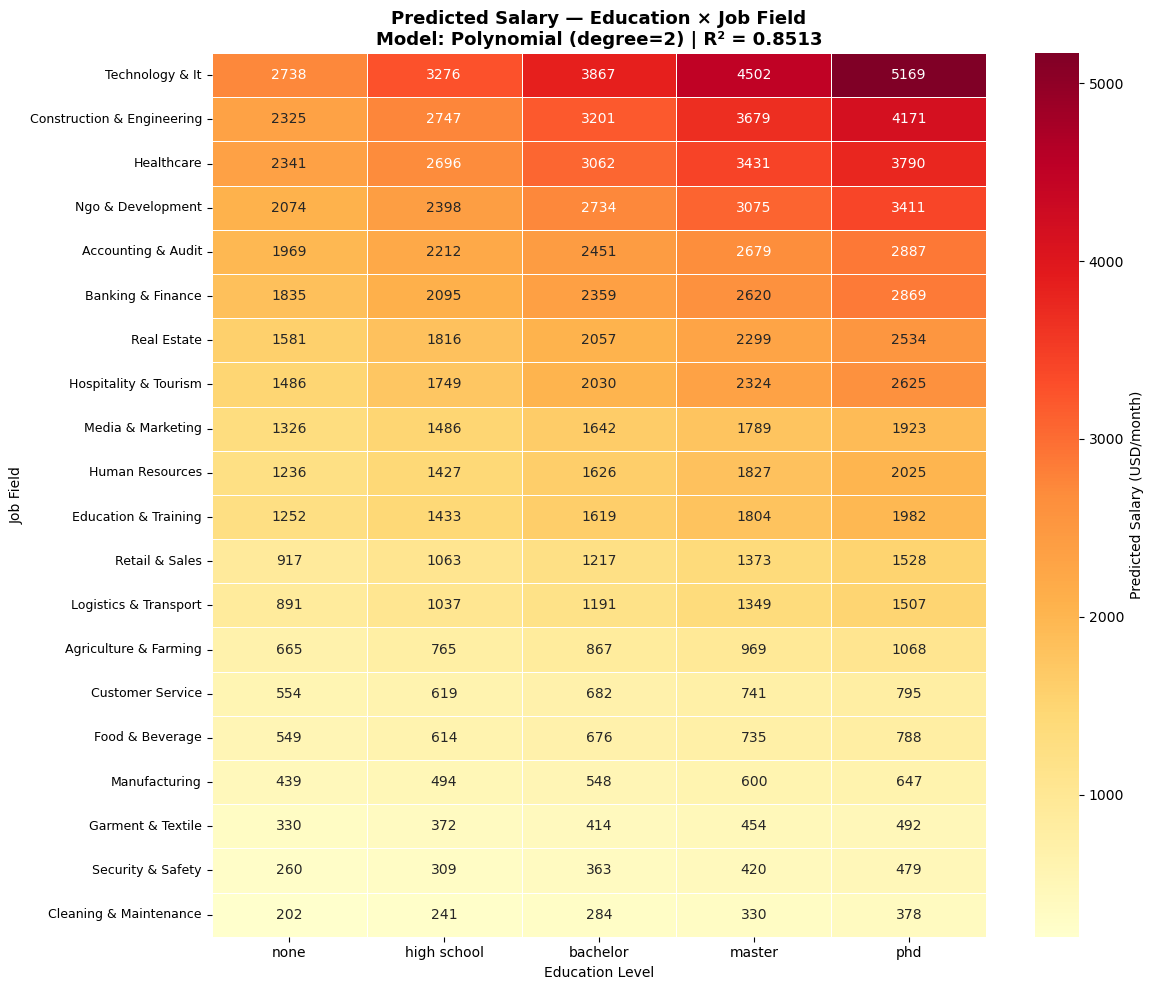

✅ Saved prediction_heatmap.png


In [27]:
# Cell 11 — Pick Best Model & Build Prediction Heatmap
best = max(results, key=lambda x: x['R²'])
best_pipe = best['pipe']

# Refit on ALL data before saving
best_pipe.fit(X, y)

print(f"✅ Best Model : {best['Model']}")
print(f"   R²         : {best['R²']:.4f}")
print(f"   CV R²      : {best['CV R²']:.4f}")
print(f"   RMSE       : ${best['RMSE']:,.0f}/month")

# Build prediction grid
edu_levels  = ['none', 'high school', 'bachelor', 'master', 'phd']
edu_num_map = {'none': 0, 'high school': 1, 'bachelor': 2,
               'master': 3, 'phd': 4}
job_fields  = sorted(df_model['category'].astype(str).unique())

rows = []
for edu in edu_levels:
    for field in job_fields:
        rows.append({
            'edu_numeric': edu_num_map[edu],
            'category'   : field,
            'edu_label'  : edu
        })

grid = pd.DataFrame(rows)
grid['predicted_salary'] = np.expm1(
    best_pipe.predict(grid[['edu_numeric', 'category']])
)

pivot = grid.pivot_table(
    values='predicted_salary',
    index='category',
    columns='edu_label'
)[edu_levels].sort_values('bachelor', ascending=False)

# Plot heatmap
fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(
    pivot, annot=True, fmt='.0f',
    cmap='YlOrRd', linewidths=0.5,
    linecolor='white', ax=ax,
    cbar_kws={'label': 'Predicted Salary (USD/month)'}
)
ax.set_title(
    f'Predicted Salary — Education × Job Field\n'
    f'Model: {best["Model"]} | R² = {best["R²"]:.4f}',
    fontsize=13, fontweight='bold'
)
ax.set_xlabel('Education Level')
ax.set_ylabel('Job Field')
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=9)
plt.tight_layout()
plt.savefig('prediction_heatmap.png', bbox_inches='tight', dpi=120)
plt.show()
print("✅ Saved prediction_heatmap.png")

In [28]:
# Cell 12 — Save Model & All Info
os.makedirs('model', exist_ok=True)

# Save best pipeline
with open('model/best_model.pkl', 'wb') as f:
    pickle.dump(best_pipe, f)

# Save everything Streamlit needs
model_info = {
    'best_model_name' : best['Model'],
    'r2'              : best['R²'],
    'cv_r2'           : best['CV R²'],
    'rmse'            : best['RMSE'],
    'mae'             : best['MAE'],
    'job_fields'      : job_fields,
    'edu_levels'      : edu_levels,
    'edu_num_map'     : edu_num_map,
    'salary_median'   : float(df_model['salary_avg'].median()),
    'salary_mean'     : float(df_model['salary_avg'].mean()),
    'n_rows'          : len(df_model),
    'pivot_table'     : pivot,
    'all_results'     : [
        {k: v for k, v in r.items() if k not in ['pipe', 'y_pred']}
        for r in results
    ],
}

with open('model/model_info.pkl', 'wb') as f:
    pickle.dump(model_info, f)

print("✅ Saved model/best_model.pkl")
print("✅ Saved model/model_info.pkl")
print("\n🎉 Training complete! Now run:  streamlit run app.py")

✅ Saved model/best_model.pkl
✅ Saved model/model_info.pkl

🎉 Training complete! Now run:  streamlit run app.py
